## Train A Test A

### Classification

Category distribution:
4    17435
0    16023
2      483
3      448
1      202
6       47
5       29
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.90      0.91      0.90      3245
      Button       1.00      1.00      1.00        35
        Door       1.00      0.96      0.98        78
      Motion       0.91      0.62      0.74        84
      Socket       0.91      0.91      0.91      3477
 Temperature       1.00      0.80      0.89        10
   Vibration       1.00      1.00      1.00         5

    accuracy                           0.91      6934
   macro avg       0.96      0.89      0.92      6934
weighted avg       0.91      0.91      0.91      6934

Macro F1-Score: 0.9172


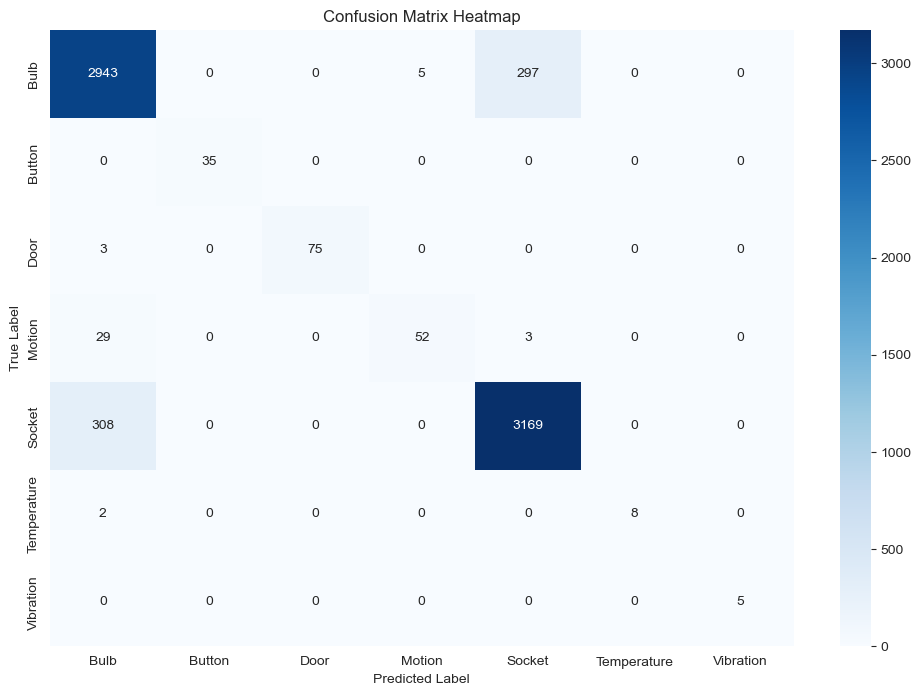

In [1]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
# Calculated Macro Average F1-Score
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
15    5396
14    5034
5     4828
13    4527
12    3842
9     2974
8     2661
10    1718
7     1326
6     1152
11     391
1      344
0      202
2      110
4       47
18      30
20      29
17      25
3       17
19      10
16       4
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.97      1.00      0.99        35
        Aqara Door 1       0.98      0.94      0.96        52
        Aqara Door 2       1.00      0.95      0.97        20
        Aqara Motion       1.00      1.00      1.00         2
     Aqara Vibration       1.00      1.00      1.00         5
       Ledvance Bulb       0.79      0.84      0.81       955
Ledvance Smart+ Plug       0.78      0.74      0.76       216
    Ledvance Z3 Plug       0.78      0.73      0.75       271
           Moes Bulb       0.89      0.82      0.86       533
      Philips Lamp 1       0.74      0.64      0.68       619
      Philips Lamp 2       0.71      

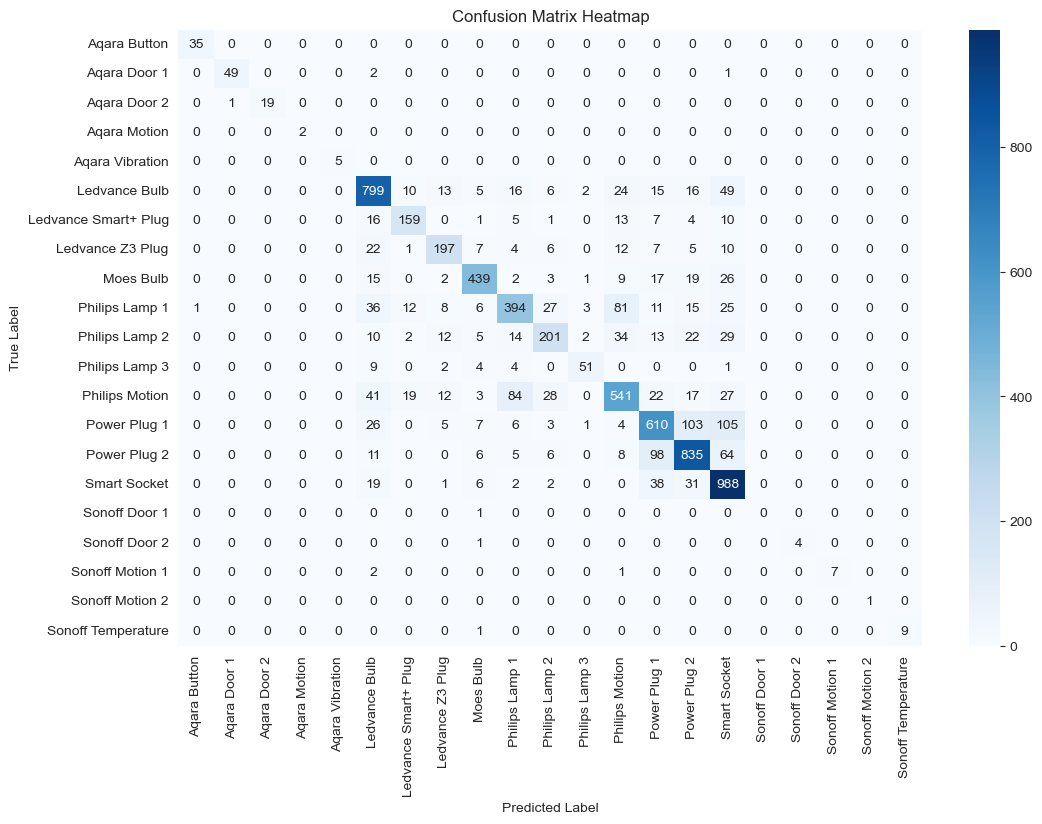

In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train B Test B

### Classification

Category distribution:
4    38858
0    17777
3      834
2      307
1      161
5      113
6       45
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.92      0.87      0.89      3605
      Button       0.95      1.00      0.97        36
        Door       0.95      0.86      0.91        72
      Motion       0.88      0.82      0.84       157
      Socket       0.94      0.96      0.95      7715
 Temperature       1.00      0.82      0.90        22
   Vibration       1.00      0.75      0.86        12

    accuracy                           0.93     11619
   macro avg       0.95      0.87      0.90     11619
weighted avg       0.93      0.93      0.93     11619

Macro F1-Score: 0.9030


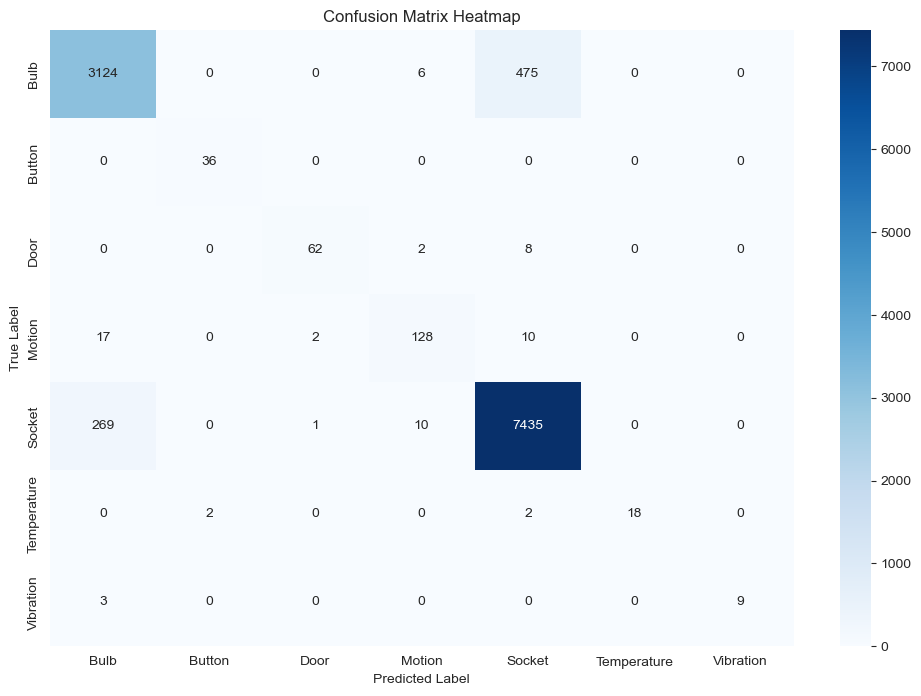

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
14    14334
15    13105
13     8460
9      5754
5      4972
11     3351
8      2078
7      1914
10     1622
6      1045
12      681
2       208
0       161
20      113
3        83
18       56
4        45
17       34
16       34
1        31
19       14
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.94      0.94      0.94        36
        Aqara Door 1       1.00      0.71      0.83         7
        Aqara Door 2       0.94      0.92      0.93        52
        Aqara Motion       1.00      0.93      0.96        14
     Aqara Vibration       1.00      0.67      0.80        12
       Ledvance Bulb       0.75      0.71      0.73      1009
Ledvance Smart+ Plug       0.74      0.72      0.73       193
    Ledvance Z3 Plug       0.74      0.67      0.71       375
           Moes Bulb       0.85      0.82      0.84       414
      Philips Lamp 1       0.79      0.80      0.79      1148
      Philips La

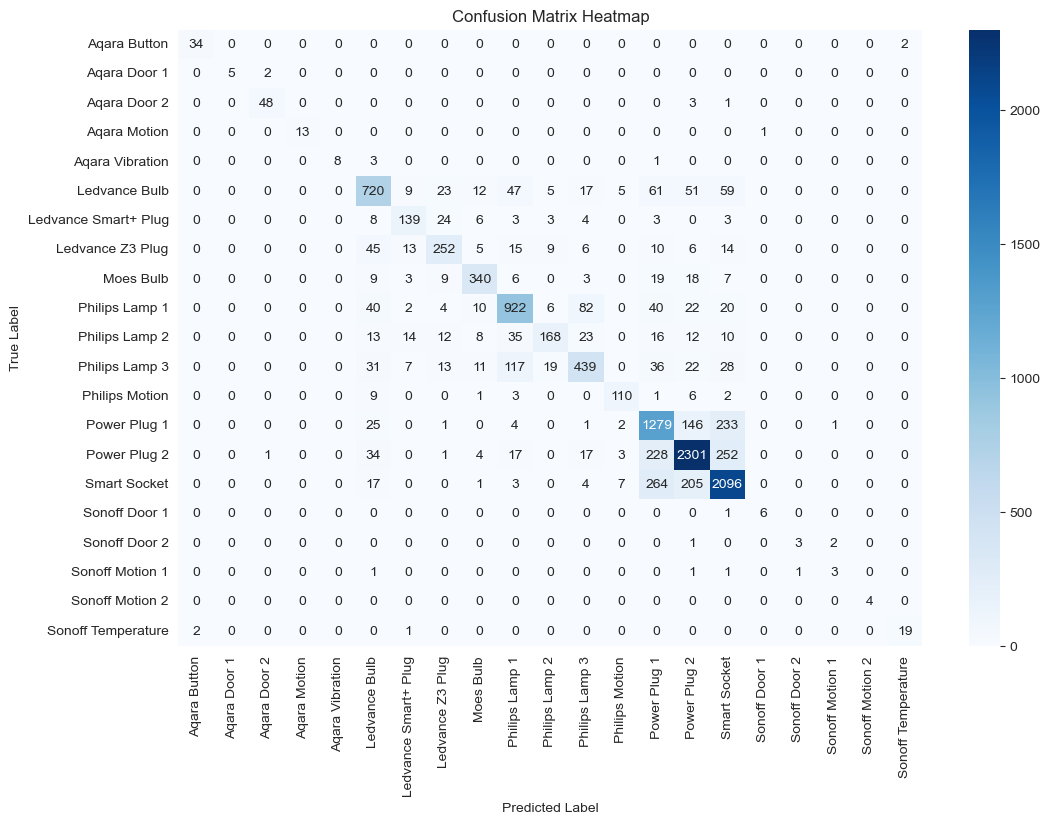

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train A Test B

### Classification

Category distribution:
4    17435
0    16023
2      483
3      448
1      202
6       47
5       29
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.56      0.80      0.66     17777
      Button       0.51      0.71      0.59       161
        Door       0.37      0.72      0.49       307
      Motion       0.52      0.19      0.28       834
      Socket       0.89      0.72      0.80     38858
 Temperature       0.37      0.12      0.18       113
   Vibration       0.00      0.00      0.00        45

    accuracy                           0.74     58095
   macro avg       0.46      0.47      0.43     58095
weighted avg       0.78      0.74      0.74     58095

Macro F1-Score: 0.4272


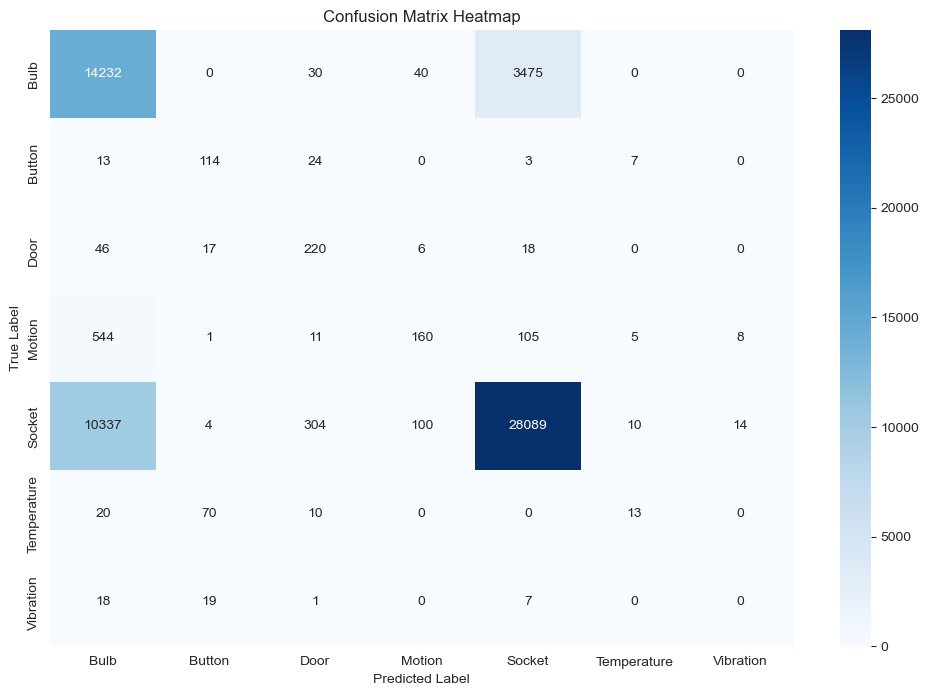

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
15    5396
14    5034
5     4828
13    4527
12    3842
9     2974
8     2661
10    1718
7     1326
6     1152
11     391
1      344
0      202
2      110
4       47
18      30
20      29
17      25
3       17
19      10
16       4
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.30      0.66      0.41       161
        Aqara Door 1       0.00      0.10      0.01        31
        Aqara Door 2       0.04      0.02      0.03       208
        Aqara Motion       0.26      0.07      0.11        83
     Aqara Vibration       0.03      0.04      0.03        45
       Ledvance Bulb       0.37      0.50      0.43      4972
Ledvance Smart+ Plug       0.14      0.09      0.11      1045
    Ledvance Z3 Plug       0.27      0.26      0.27      1914
           Moes Bulb       0.24      0.37      0.29      2078
      Philips Lamp 1       0.45      0.31      0.37      5754
      Philips Lamp 2       0.09      

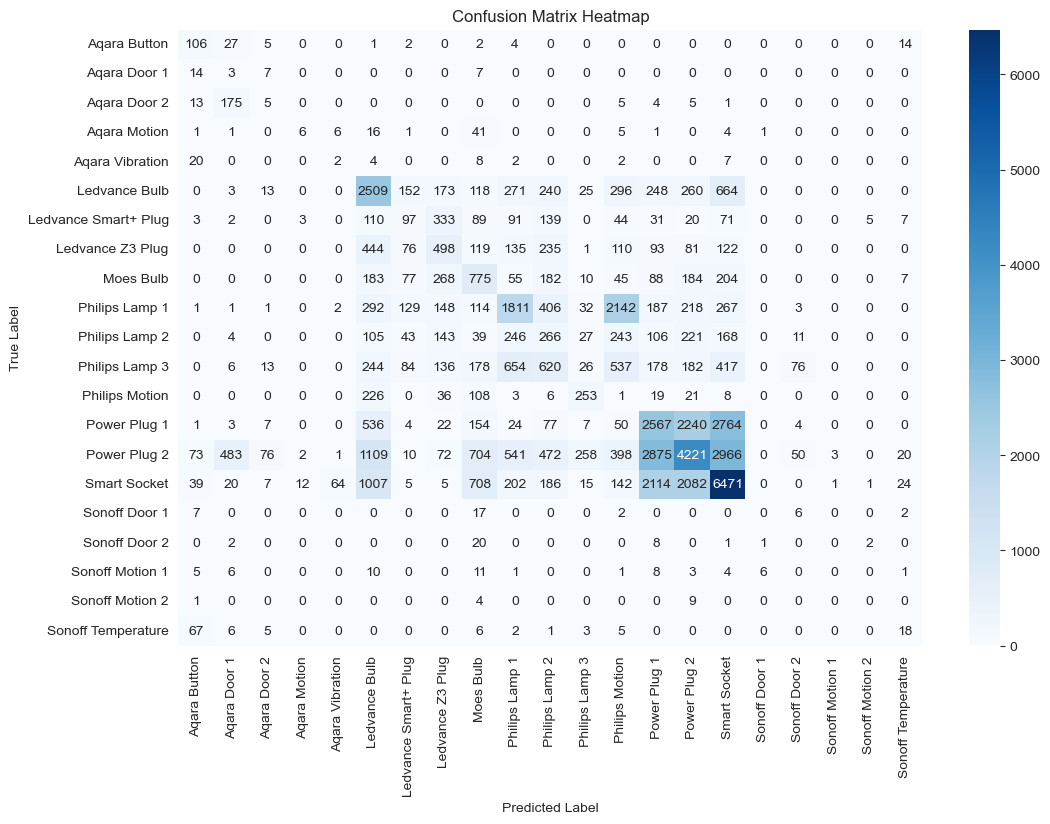

In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


## Train B Test A

### Classification

Category distribution:
4    38858
0    17777
3      834
2      307
1      161
5      113
6       45
Name: count, dtype: int64
              precision    recall  f1-score   support

        Bulb       0.80      0.75      0.77     16023
      Button       0.85      0.05      0.10       202
        Door       0.86      0.57      0.68       483
      Motion       0.36      0.25      0.30       448
      Socket       0.78      0.85      0.81     17435
 Temperature       0.09      0.24      0.14        29
   Vibration       1.00      0.43      0.60        47

    accuracy                           0.78     34667
   macro avg       0.68      0.45      0.49     34667
weighted avg       0.78      0.78      0.78     34667

Macro F1-Score: 0.4852


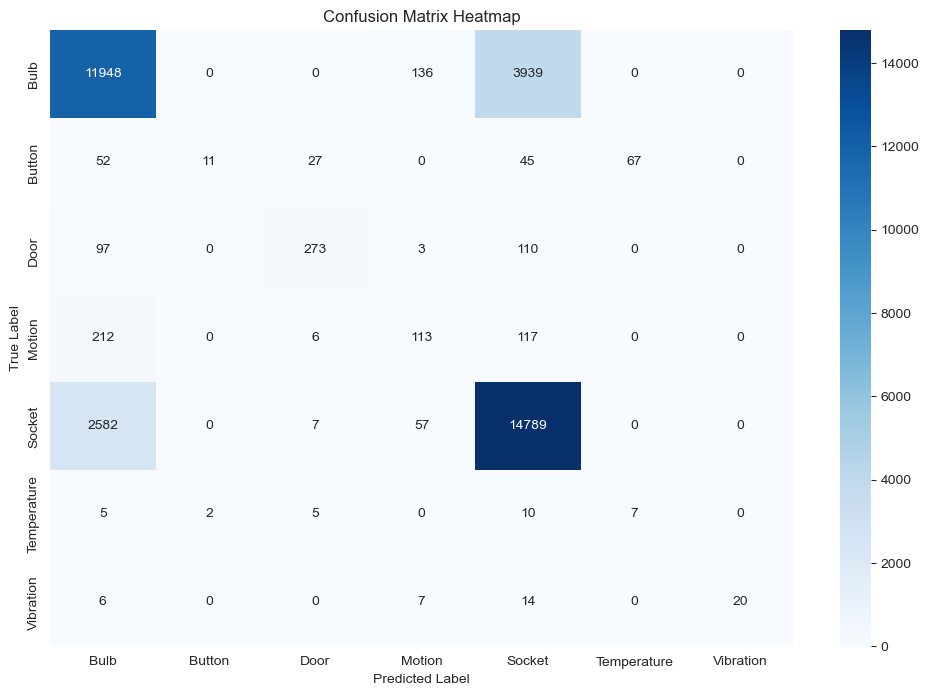

In [7]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]
y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes


class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
14    14334
15    13105
13     8460
9      5754
5      4972
11     3351
8      2078
7      1914
10     1622
6      1045
12      681
2       208
0       161
20      113
3        83
18       56
4        45
17       34
16       34
1        31
19       14
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.00      0.00      0.00       202
        Aqara Door 1       0.29      0.01      0.02       344
        Aqara Door 2       0.04      0.09      0.05       110
        Aqara Motion       0.36      0.24      0.29        17
     Aqara Vibration       0.00      0.00      0.00        47
       Ledvance Bulb       0.58      0.55      0.57      4828
Ledvance Smart+ Plug       0.29      0.12      0.17      1152
    Ledvance Z3 Plug       0.34      0.26      0.30      1326
           Moes Bulb       0.72      0.30      0.43      2661
      Philips Lamp 1       0.29      0.58      0.39      2974
      Philips La

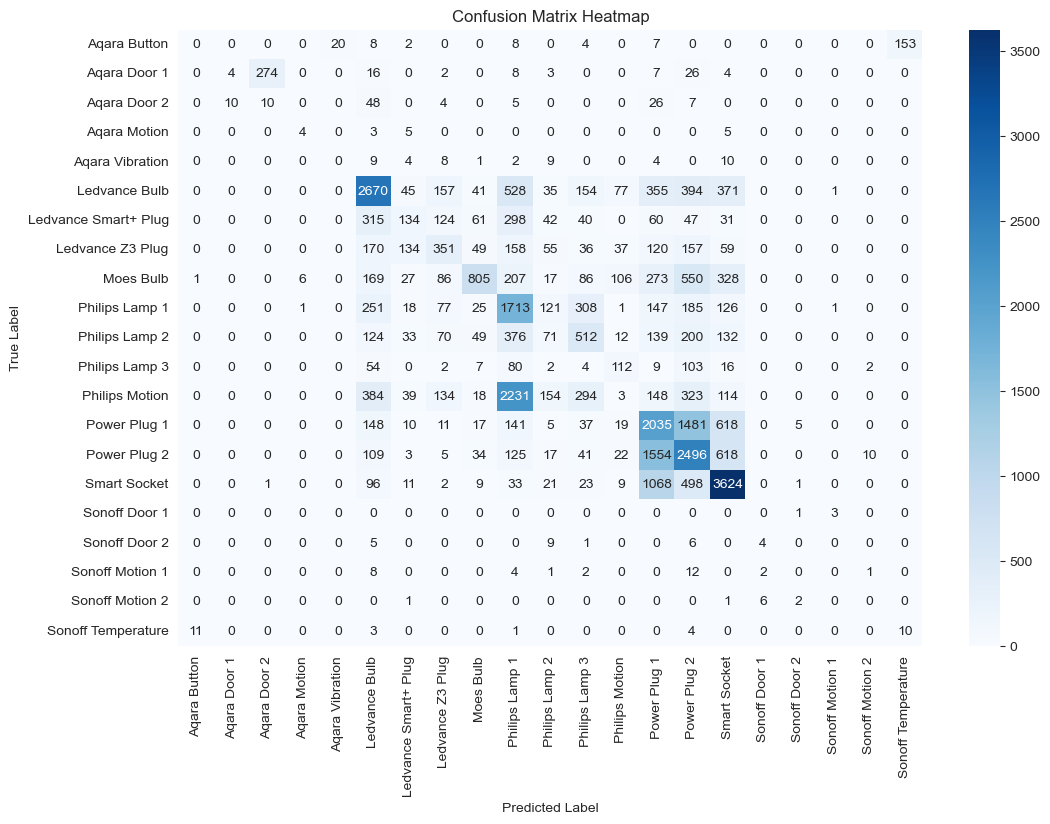

In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()
